# Exploratory Data Analysis cacao dataset na SAD

okej to zacznijmy od zimportowania bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

okej teraz dataset wyczyszczony importujemy

In [2]:
cacao = pd.read_csv('flavors_of_cacao_clean.csv')

In [3]:
cacao.head(5)

,company,product_name,reference_id,review_year,cocoa_percent,company_location,rating,bean_type,bean_origin,is_dark,rating_grade
0,A. Morin,Agua Grande,1876,2016,63.0,France,3.75,NaN,NaN,False,Premium
1,A. Morin,Kpime,1676,2015,70.0,France,2.75,NaN,NaN,True,Poprawny
2,A. Morin,Atsane,1676,2015,70.0,France,3.00,NaN,NaN,True,Poprawny
3,A. Morin,Akata,1680,2015,70.0,France,3.50,NaN,NaN,True,Premium
4,A. Morin,Quilla,1704,2015,70.0,France,3.50,NaN,NaN,True,Premium


# ETAP I



średnia rating

In [7]:
float(cacao["rating"].mean().round(2))

3.19

mediana rating

In [8]:
cacao["rating"].median()

3.25

odchylenie standardowe rating

In [9]:
cacao["rating"].std()

0.47766761134655794

min i max rating

In [10]:
cacao["rating"].apply(lambda x: round(x, 2)).min(), cacao["rating"].apply(lambda x: round(x, 2)).max()

(1.0, 5.0)

kwartyle rating

In [11]:
cacao["rating"].quantile([0.25, 0.5, 0.75])

0.25    3.00
0.50    3.25
0.75    3.50
Name: rating, dtype: float64

histogram rating

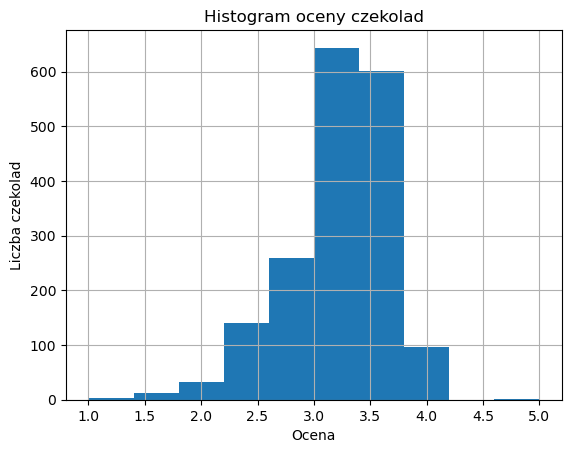

In [26]:
cacao["rating"].hist()
plt.title("Histogram oceny czekolad")
plt.xlabel("Ocena")
plt.ylabel("Liczba czekolad")
plt.show()

boxplot rating

<Axes: >

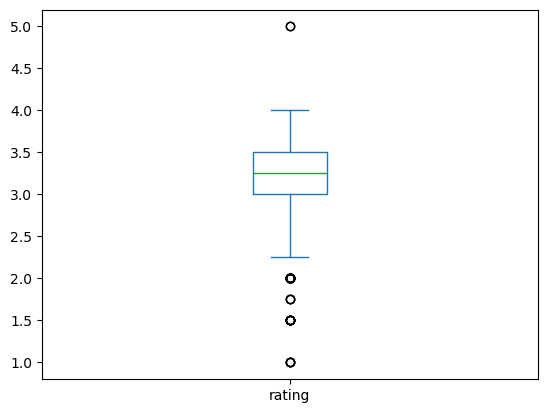

In [17]:
cacao["rating"].plot(kind="box")
plt.title("Boxplot oceny czekolad")
plt.show()

okej jeśli chodzi o krótki opis to rating wygląda tak, że z boxplotu wynika że jest 5 outlinerów, większość z oceną poniżej std, że większość ocen jest między 3.0 a 3.7, roztęp między kwartylami jest dość duży, co sugeruje dużą rozpiętość ocen i średnią jakość czekolad. odchylenie standardowe potwierdza tą hipotezę, charakter rozkładu jest prawie normalny, z lekkim prawoskośnym rozkładem, że jest lekka tendencja do większej jakośći

# Etap II - EDA

bierzemy pod uwagę marki zależne

1.

In [21]:
rating_by_country =cacao.groupby("company_location")["rating"].mean().sort_values(ascending=False)

rating_by_country.head(10)

company_location
Chile          3.750000
Amsterdam      3.500000
Netherlands    3.500000
Philippines    3.500000
Iceland        3.416667
Vietnam        3.409091
Brazil         3.397059
Poland         3.375000
Australia      3.357143
Guatemala      3.350000
Name: rating, dtype: float64

In [24]:
pos = rating_by_country.index.get_loc('Poland') + 1
print(f"Polska jest na miejscu {pos}")

Polska jest na miejscu 8


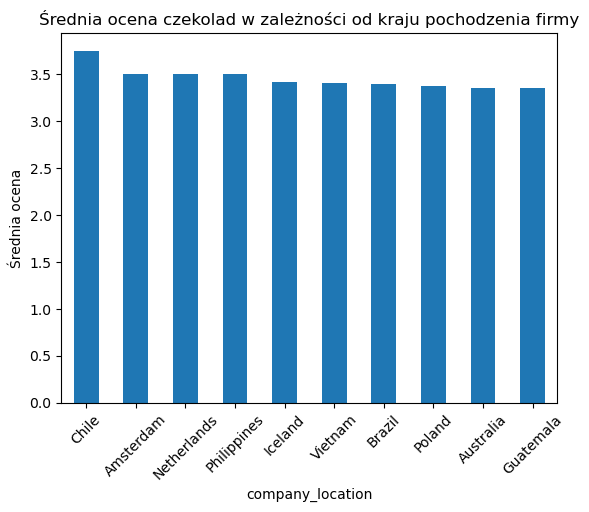

In [25]:
rating_by_country.head(10).to_frame().plot(kind="bar", legend=False)
plt.ylabel("Średnia ocena")
plt.title("Średnia ocena czekolad w zależności od kraju pochodzenia firmy")
plt.xticks(rotation=45)
plt.show()

2.

In [34]:
biggest_country = cacao["company_location"].value_counts()
biggest_country.head(20)

company_location
U.S.A.         763
France         156
Canada         124
U.K.            96
Italy           63
Ecuador         55
Australia       49
Belgium         40
Switzerland     38
Germany         35
Austria         26
Spain           25
Colombia        23
Hungary         22
Venezuela       20
New Zealand     17
Japan           17
Peru            17
Brazil          17
Madagascar      17
Name: count, dtype: int64

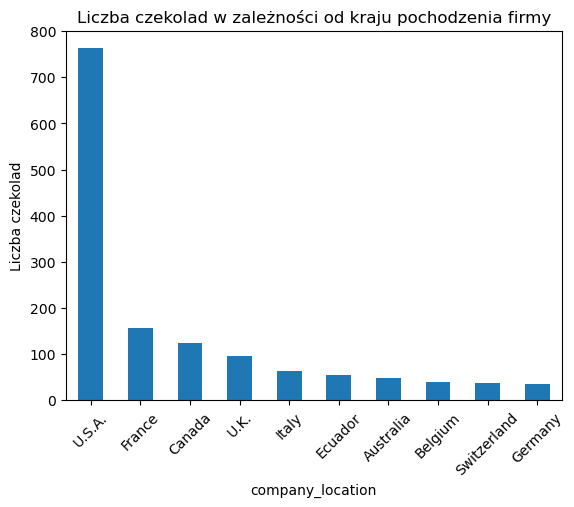

In [31]:
biggest_country.head(10).to_frame().plot(kind="bar", legend=False)
plt.ylabel("Liczba czekolad")
plt.title("Liczba czekolad w zależności od kraju pochodzenia firmy")
plt.xticks(rotation=45)
plt.show()

zdecydowanie najwięcej czekolad jest z USA, reszta krajów ma dużo mniej czekolad, Polska jest na 11 miejscu.

# 3.

In [52]:
print(cacao[["cocoa_percent", "rating"]].corr())

               cocoa_percent    rating
cocoa_percent       1.000000 -0.164758
rating             -0.164758  1.000000


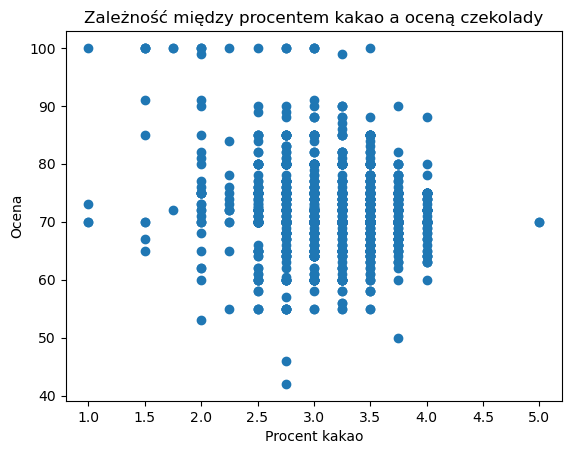

In [56]:
plt.scatter(cacao["rating"], cacao["cocoa_percent"])
plt.title("Zależność między procentem kakao a oceną czekolady")
plt.xlabel("Procent kakao")
plt.ylabel("Ocena")
plt.show()

Text(0.5, 1.0, 'rozkład gęstości')

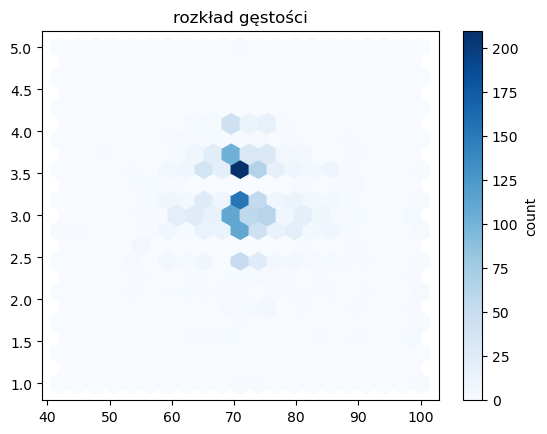

In [58]:
plt.hexbin(cacao["cocoa_percent"], cacao["rating"], gridsize=20, cmap="Blues")
plt.colorbar(label="count")
plt.title("rozkład gęstości")


dobra z korelacji wynoszacej -0.164758, co oznacza że jest słaba ujemna korelacja między procentem kakao a oceną czekolady, co sugeruje że wyższy procent kakao może być związany z niższymi ocenami, ale ta zależność jest dość słaba i może być wpływana przez inne czynniki.


# 4.

In [33]:
cacao["is_dark"].value_counts()

is_dark
True     1465
False     328
Name: count, dtype: int64

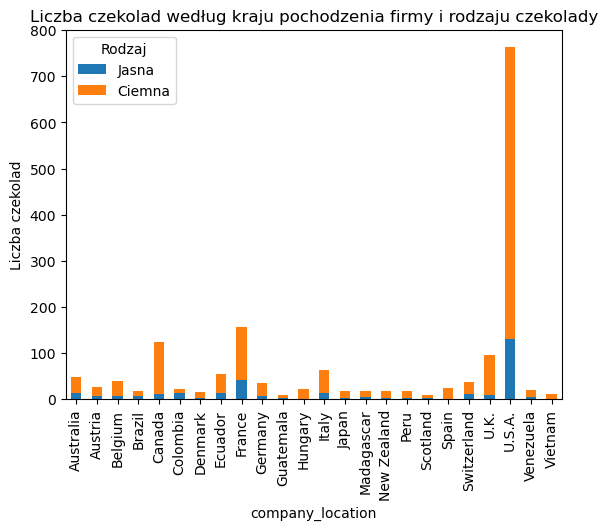

In [41]:
valid_countries = biggest_country[biggest_country >= 10].index

plot_df = (
    cacao[cacao["company_location"].isin(valid_countries)]
    .groupby(["company_location", "is_dark"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plot_df.columns = ["Jasna", "Ciemna"] if set(plot_df.columns) == {False, True} else plot_df.columns

plot_df.plot(kind="bar", stacked=True)
plt.ylabel("Liczba czekolad")
plt.title("Liczba czekolad według kraju pochodzenia firmy i rodzaju czekolady")
plt.xticks(rotation=90)
plt.legend(title="Rodzaj")
plt.show()

total_dark = plot_df["Ciemna"].sum() if "Ciemna" in plot_df.columns else plot_df[True].sum()
total_light = plot_df["Jasna"].sum() if "Jasna" in plot_df.columns else plot_df[False].sum()


zdecydowanie bardziej popularna jest ciemna czekolada, jest jej 3 razy więcej niż mlecznej

# 5.

Średnia ocena w kolejnych latach

In [42]:
yearly_mean = cacao.groupby("review_year")["rating"].mean().sort_index()

Średnia ocena w kolejnych latach z podziałem na typ czekolady

In [44]:
yearly_by_type = (
    cacao.groupby(["review_year", "is_dark"])["rating"]
    .mean()
    .unstack()
    .sort_index()
)

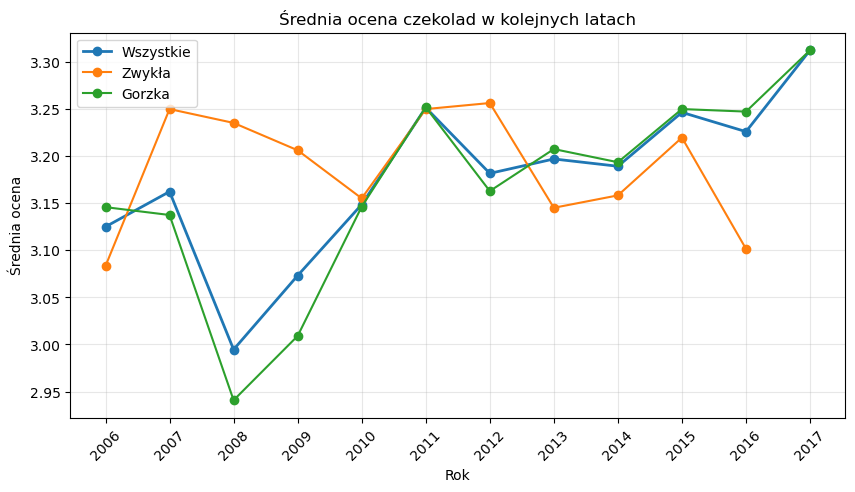

In [45]:
yearly_by_type.columns = ["Zwykła", "Gorzka"]

plt.figure(figsize=(10, 5))
plt.plot(yearly_mean.index, yearly_mean.values, marker="o", linewidth=2, label="Wszystkie")
plt.plot(yearly_by_type.index, yearly_by_type["Zwykła"], marker="o", label="Zwykła")
plt.plot(yearly_by_type.index, yearly_by_type["Gorzka"], marker="o", label="Gorzka")

plt.title("Średnia ocena czekolad w kolejnych latach")
plt.xlabel("Rok")
plt.ylabel("Średnia ocena")
plt.xticks(yearly_mean.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Średnia ocena ogółem w latach

In [43]:
yearly_mean.round(3)

review_year
2006    3.125
2007    3.162
2008    2.995
2009    3.073
2010    3.149
2011    3.252
2012    3.182
2013    3.197
2014    3.189
2015    3.246
2016    3.226
2017    3.312
Name: rating, dtype: float64

# Wnioski

1. Najwyższą średnią ocenę ma Chile
2. Najwięcej czekolad jest z USA, Polska jest na 11 miejscu
3. Jest słaba ujemna korelacja między procentem kakao a oceną
4. Większość czekolad jest gorzka
5. średnia ocena w kolejnych latach jest dość stabilna, z lekkim wzrostem w ostatnich latach, a ciemna czekolada ma wyższe oceny niż mleczna.